# CIFAR-100 Image Classification with **CNN** and **Data Augmentation**

In [1]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.datasets import cifar100
from keras.layers import (Conv2D, Activation, BatchNormalization,
                          MaxPooling2D, GlobalAveragePooling2D,
                          Dense, Dropout, Softmax)
from keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Loading the CIFAR-100 Dataset

The CIFAR-100 dataset is loaded using the `fine` label mode, which provides 100 detailed image classes.

The dataset is split into:

- **Training set:** used to train the CNN model.
- **Test set:** used to evaluate the model on unseen images.

This cell also prints the shapes of the image arrays and label arrays to verify that the dataset has been loaded correctly.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode= 'fine')
print(f'X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\n'\
      f'X_test shape: {X_test.shape}\ny_test shape: {y_test.shape}')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1339s 8us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


## Data Normalization
Pixel values are converted to `float32` and scaled from `[0, 255]` to `[0.0, 1.0]` to accelerate model convergence and improve numerical stability during training.


In [3]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

## Label Shape Update
The target labels were squeezed from shape `(N, 1)` to `(N,)` for compatibility with model training and evaluation.


In [4]:
y_train = np.squeeze(y_train)
y_test = np.squeeze(y_test)

In [5]:
fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee',
    'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus',
    'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch',
    'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant',
    'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo',
    'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road',
    'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar',
    'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
    'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## Visualize a CIFAR-100 Image

The `fine_labels` list maps each numeric label to its corresponding class name.  
A selected training image is displayed with its class label.


Enter the number of image: 45000


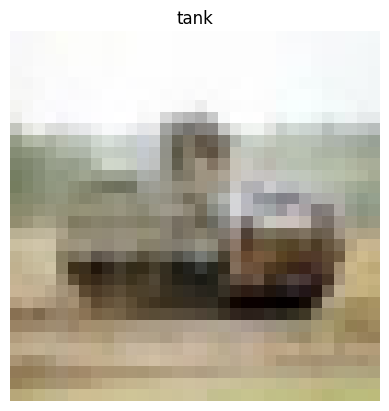

In [6]:
i = int(input('Enter the number of image: '))
plt.imshow(X_train[i])
plt.title(fine_labels[y_train[i]]);
plt.axis('off');

### Configuring Data Augmentation

We initialize an `ImageDataGenerator` to apply real-time data transformations to the training dataset. This helps the model generalize better by introducing variations such as flips, shears, zooms, and shifts.

The augmented images are then streamed through `train_datagen.flow()`, which handles batching and shuffling dynamically during training.


In [8]:
train_datagen = ImageDataGenerator(rotation_range= 0.3,
                                   zoom_range= 0.2,
                                   shear_range= 0.3,
                                   horizontal_flip= True,
                                   vertical_flip= True,
                                   fill_mode= 'constant',
                                   width_shift_range= 0.2,
                                   height_shift_range= 0.3)

train_generation = train_datagen.flow(X_train_norm,
                                      y_train,
                                      batch_size= 32,
                                      shuffle= True)